### Data Dependencies

In [2]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily) # smote
library(janitor)     # data cleaning
library(tidyverse) 
library(randomForest)
library(xgboost)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:rsample’:

    calibration



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to

### Cleaning Data 

In [6]:
set.seed(100)

# Load & Clean Column Names
merged <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> 
  clean_names()

# Train/test split 
strata <- ifelse(merged$outbreak > 0, "nonzero", "zero")
index  <- createDataPartition(strata, p = 0.75, list = FALSE)
train  <- merged[index, ]
test   <- merged[-index, ]

# Drop county and NA columns 
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

# Ensure all columns are numeric 
non_num <- names(train)[!sapply(train, is.numeric)]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

# Mirror same cleaning on test set 
test <- test[, names(test) %in% c(names(train), "outbreak")]

non_num_test <- names(test)[!sapply(test, is.numeric) & names(test) != "outbreak"]
if (length(non_num_test) > 0) {
  test[non_num_test] <- lapply(test[non_num_test], as.numeric)
}

test <- test |>
  mutate(across(
    .cols = -outbreak,
    .fns  = ~ifelse(is.na(.), train_medians[cur_column()], .)
  ))

test$outbreak <- as.numeric(test$outbreak)

stopifnot(sum(is.na(test)) == 0)

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Test rows:",  nrow(test),  "| Cols:", ncol(test),  "\n")

# Export to csv
write_csv(train, "data/created/train_clean.csv")
write_csv(test,  "data/created/test_clean.csv")

Train rows: 191 | Cols: 220 
Test rows: 63 | Cols: 220 


### SMOGN (IN PYTHON RUN DIFFERENT KERNEL)

In [1]:
import numpy as np
import pandas as pd
import smogn

# ── 1. Load cleaned train data from R ─────────────────────────────────────
train = pd.read_csv("data/created/train_clean.csv")
randomseed = 100

'''
print("Outbreak distribution before SMOGN:")
print(train["outbreak"].value_counts().sort_index())
print("Train shape:", train.shape)

# ── 2. Inspect outbreak range to set control points ───────────────────────
print("\nOutbreak summary:")
print(train["outbreak"].describe())
'''

# ── 3. Apply SMOGN with manual relevance control points ───────────────────
# rel_ctrl_pts_rg format: [[x, y, derivative], ...]
# x = outbreak value, y = relevance (0 = common, 1 = rare)
# Set low outbreak counts as common (0) and high counts as rare (1)

train_balanced = smogn.smoter(
    data          = train,
    y             = "outbreak",
    k             = 5,          # number of nearest neighbors for synthetic sample generation
    samp_method   = "balance",  # balance the dataset by generating synthetic samples for the minority class
    seed = randomseed,          # for reproducibility
    rel_thres     = 0.5,        # threshold for determining which samples are considered rare vs common based on relevance (default)
    rel_method    = "manual",   # use manual relevance control points to define relevance of outbreak values
    rel_ctrl_pts_rg = [
        [0, 0, 0],              # 0 is common value
        [2, 1, 0],               # 2 is uncommon and needs to be over sampled            
    ]
)

print("\nOutbreak distribution after SMOGN:")
print(train_balanced["outbreak"].value_counts().sort_index())
print("Train balanced shape:", train_balanced.shape)


# ── 4. Export balanced train set back for R modeling ──────────────────────
train_balanced.to_csv("data/created/train_balanced.csv", index=False)

r_index: 100%|##########| 11/11 [00:00<00:00, 77.27it/s]



Outbreak distribution after SMOGN:
outbreak
0.0      74
1.0      30
2.0       7
3.0       9
4.0       2
5.0       5
6.0       2
7.0       4
8.0       3
9.0       3
12.0      4
14.0      1
18.0      1
19.0      1
26.0      1
28.0      1
29.0      1
31.0      1
36.0      1
47.0      1
52.0      2
59.0      2
60.0      1
63.0      1
85.0      1
414.0     2
415.0     1
Name: count, dtype: int64
Train balanced shape: (162, 220)


### Initial testing of regression model using basic tree (No tuning)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 34.5757 
MAE  (Mean Absolute Error)   : 11.4285 
R-squared                    : 0.1519 


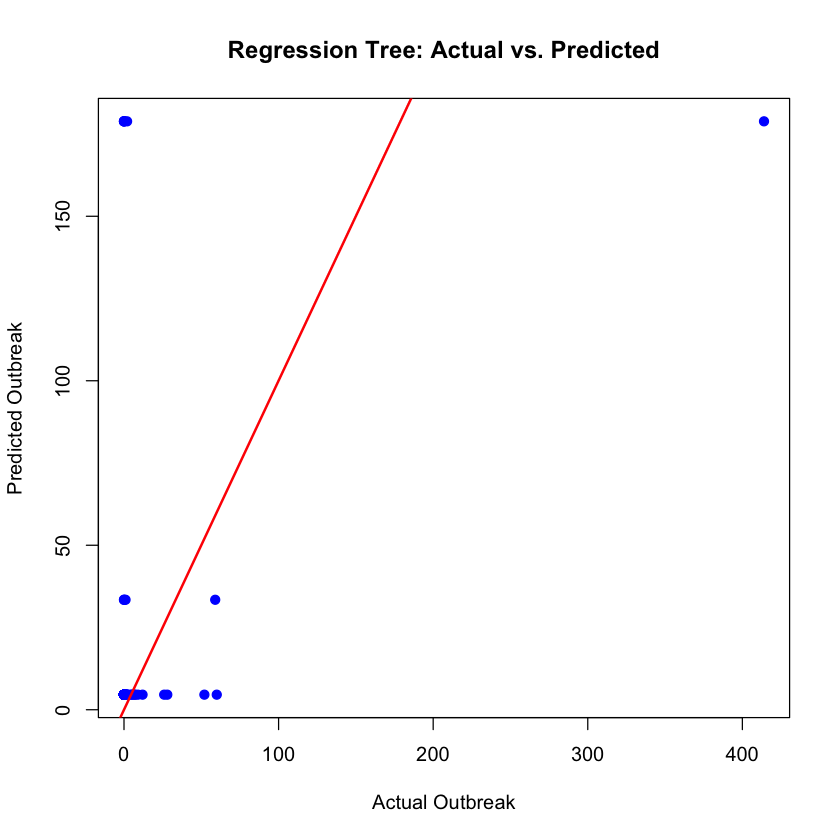

In [7]:
# Read data form CSV
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE) 
test  <- read_csv("data/created/test_clean.csv", show_col_types = FALSE) 

# Train model 
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "anova")
#rpart.plot(dtree_model)

# Eval Performance
predictions <- predict(dtree_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
dtree_rmse <- sqrt(mean((actual_values - predictions)^2))
dtree_mae  <- mean(abs(actual_values - predictions))
dtree_r2   <- cor(actual_values, predictions)^2

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(dtree_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)    :", round(dtree_mae, 4), "\n")
cat("R-squared                     :", round(dtree_r2, 4), "\n")

# Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree: Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line


### Random Forest (No optimization)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 12.4702 
MAE  (Mean Absolute Error)   : 4.8994 
R-squared                    : 0.8653 


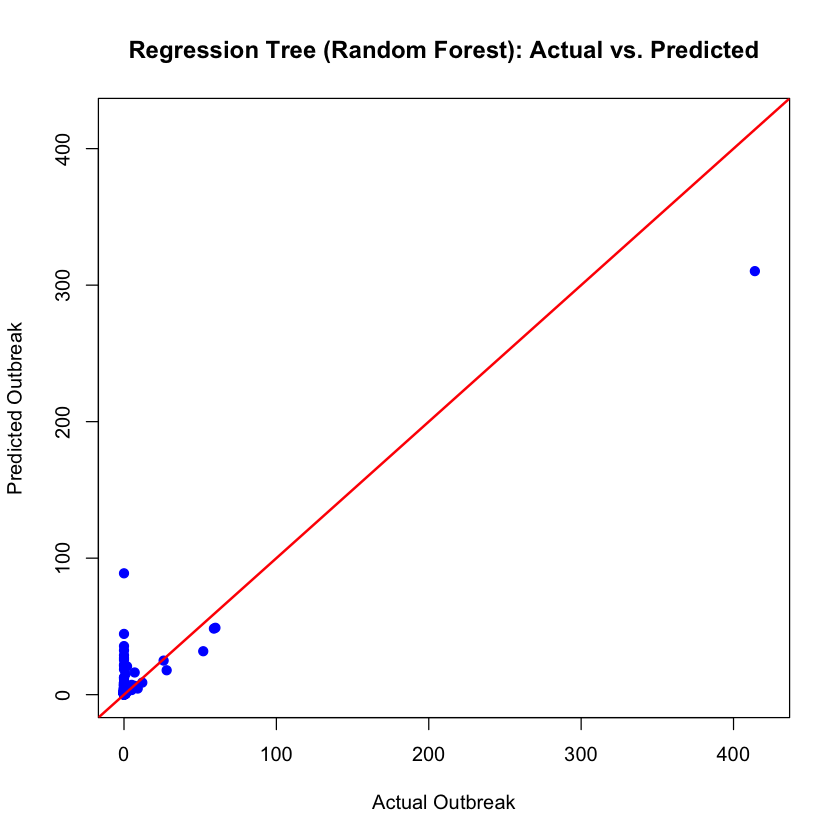

In [10]:
# Train Model
rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

predictions <- predict(rforest_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
rforest_rmse <- sqrt(mean((actual_values - predictions)^2))
rforest_mae  <- mean(abs(actual_values - predictions))
rforest_r2   <- cor(actual_values, predictions)^2

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(rforest_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)   :", round(rforest_mae, 4), "\n")
cat("R-squared                    :", round(rforest_r2, 4), "\n")

# #Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree (Random Forest): Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     xlim = c(0, 420), ylim = c(0, 420),
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

### Boosted Tree (No optimization)

Regression Tree Accuracy Metrics (Original Train):
RMSE: 4.1693 
MAE : 1.9036 
R-squared : 0.9836 


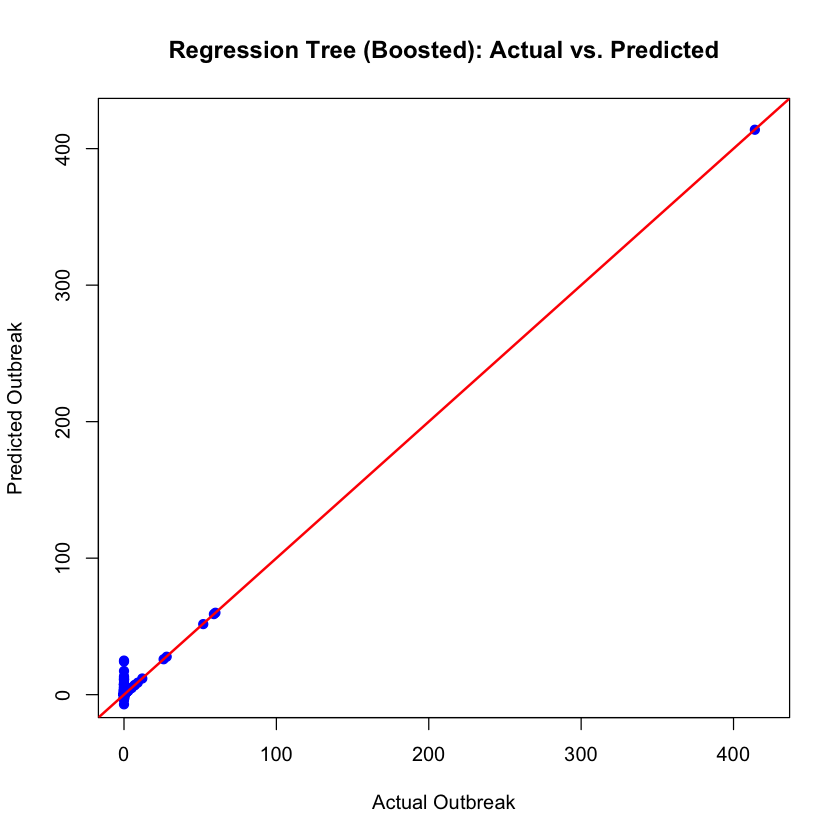

In [11]:
# 1. Prepare data
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

# Prepare the original data for prediction
# Note: ogtrain should be a DMatrix so xgboost can read it
X_og <- as.matrix(train[, names(train) != "outbreak"])
ogtrain <- xgb.DMatrix(data = X_og) 

# 2. Train the model
boost_model <- xgb.train(
  params = list(
    objective = "reg:squarederror",
    eval_metric = "rmse",
    max_depth = 3,
    eta = 0.1
  ),
  data = dtrain,
  nrounds = 500
)

# 3. Predict on the ORIGINAL training set
predictions <- predict(boost_model, ogtrain) # Use dogtrain, not dtrain
actual_values <- as.numeric(as.character(train$outbreak)) # Pull from original 'train' dataframe

# 4. Calculate metrics (dimensions now match)
rforest_rmse <- sqrt(mean((actual_values - predictions)^2))
rforest_mae <- mean(abs(actual_values - predictions))
rforest_r2 <- cor(actual_values, predictions)^2

# Print results
cat("Regression Tree Accuracy Metrics (Original Train):\n")
cat("RMSE:", round(rforest_rmse, 4), "\n")
cat("MAE :", round(rforest_mae, 4), "\n")
cat("R-squared :", round(rforest_r2, 4), "\n")

# #Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree (Boosted): Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     xlim = c(0, 420), ylim = c(0, 420),
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line